# ML from DFT data

In [1]:
import pickle
import os
import glob
import numpy as np
import pdb
import pandas as pd
from importlib.machinery import SourceFileLoader
import re
import sys
from tqdm.notebook import tqdm_notebook
from seaborn import heatmap
import seaborn as sns
from BopFoxFeaturizer.HelperFunctions import get_useful_features
from BopFoxFeaturizer.HelperFunctions import cleanfeaturenames
from BopFoxFeaturizer.HelperFunctions import histoff_realfeatures
import matplotlib.pyplot as plt
plt.style.use('default')
plt.rc('figure', figsize=(15,10))
plt.rc('legend',fontsize=24)
plt.rc('axes',labelsize=28)
plt.rc('xtick',labelsize=24)
plt.rc('ytick',labelsize=24)
from BopFoxFeaturizer.FeatureConcatenate import stackdata
from BopFoxFeaturizer.brief_summary_parser import StructSummaryParser
from BopFoxFeaturizer.Featurizer import Featurizer
from BopFoxFeaturizer import HelperFunctions as HF
#stackdata = SourceFileLoader('stackdata','BopFoxFeaturizer/FeatureConcatenate.py').load_module().stackdata
# Original DFT Data
%run SourceDevelopementVersion.py
# which loads Featu
import glob

# Parameters 

In [2]:
CASE = 'INITIAL'  #, 'INITIAL', RELAXED
MODEL = 'ORTHOGONALOS' #, 'ORTHOGONAL', 'CANONICAL','ORTOGONALOS'
CUT_OFF = 'TABLECUTOFF' # 'TABLECUTOFF', 'HISTCUTOFF'
E_MODE ='WUBIND'
C_RITERION = 'test_score'  # test_score, train_score, err
SEARCH_MODE = 'score_only' #score_only, index_too
TARGET = 'EF'
MOMENTS = 15

# Helpeer Functions 

In [3]:
from Tools import CaseNamer, Plotting

In [4]:
FileNames = CaseNamer(
    CASE, MODEL,
    CUTOFF=CUT_OFF, EMODE=E_MODE, CRITERION=C_RITERION, SEARCHMODE=SEARCH_MODE, TARGET=TARGET
)

# Load Features

## Load briefsummary and its features

In [5]:
BS = StructSummaryParser().BriefSummary
Features = Featurizer(BS)

## Load the BOP for the selected case

In [6]:
BOPCOEF_FILE = f'CNAveragedCRCOW_{CASE}_NSC_{MODEL}_{CUT_OFF}_{E_MODE}_{MOMENTS}.pkl'
BopfoxFeatures = pd.read_pickle(BOPCOEF_FILE)
#BopfoxFeatures.drop(columns=['NSC_U_bond_atom_list'], inplace=True)
#BopfoxFeatures.drop(columns=['NSC_U_bind'], inplace=True)

In [7]:
BopfoxFeatures

,all_NSC_U_bind_0,all_NSC_U_bond_atom_0,all_NSC_U_bond_atom_list_0,CN12_NSC_U_bond_atom_list_0,CN13_NSC_U_bond_atom_list_0,CN14_NSC_U_bond_atom_list_0,CN15_NSC_U_bond_atom_list_0,CN16_NSC_U_bond_atom_list_0,all_NSC_moments_0,all_NSC_moments_1,...,CN13_NSC_Ainf_0,CN14_NSC_Ainf_0,CN15_NSC_Ainf_0,CN16_NSC_Ainf_0,all_NSC_Binf_0,CN12_NSC_Binf_0,CN13_NSC_Binf_0,CN14_NSC_Binf_0,CN15_NSC_Binf_0,CN16_NSC_Binf_0
Co_pv10W_sv14.C36-ABBAB.FM,-294.347975,-335.840358,-27.763904,-38.588728,0.0,0.000000,0.0,-6.114258,-5.46,42.872496,...,0.0,0.000000,0.0,-6.578786,5.830383,5.872895,0.0,0.00000,0.0,5.745359
Co_pv10W_sv14.C36-ABBAB.NM,-294.347975,-335.840358,-27.763904,-38.588728,0.0,0.000000,0.0,-6.114258,-5.46,42.872496,...,0.0,0.000000,0.0,-6.578786,5.830383,5.872895,0.0,0.00000,0.0,5.745359
Co_pv10W_sv14.C36-ABBBA.FM,-294.347975,-335.840358,-27.763904,-38.588728,0.0,0.000000,0.0,-6.114258,-5.46,42.872496,...,0.0,0.000000,0.0,-6.578786,5.830383,5.872895,0.0,0.00000,0.0,5.745359
Co_pv10W_sv14.C36-ABBBA.NM,-294.347975,-335.840358,-27.763904,-38.588728,0.0,0.000000,0.0,-6.114258,-5.46,42.872496,...,0.0,0.000000,0.0,-6.578786,5.830383,5.872895,0.0,0.00000,0.0,5.745359
Co_pv10W_sv14.C36-BABAB.FM,-294.347975,-335.840358,-27.763904,-38.588728,0.0,0.000000,0.0,-6.114258,-5.46,42.872496,...,0.0,0.000000,0.0,-6.578786,5.830383,5.872895,0.0,0.00000,0.0,5.745359
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
W_sv1.bcc.FM,-21.021407,-21.021407,-21.021407,0.000000,0.0,0.000000,0.0,0.000000,-5.56,53.437900,...,0.0,0.000000,0.0,0.000000,6.222663,0.000000,0.0,0.00000,0.0,0.000000
W_sv2.hcp.FM,-40.187813,-40.187813,-30.140859,0.000000,0.0,0.000000,0.0,0.000000,-5.56,52.935100,...,0.0,0.000000,0.0,0.000000,5.187294,0.000000,0.0,0.00000,0.0,0.000000
W_sv4.fcc-cubic.FM,-81.028519,-81.028519,-35.449977,0.000000,0.0,0.000000,0.0,0.000000,-5.56,52.935100,...,0.0,0.000000,0.0,0.000000,5.763108,0.000000,0.0,0.00000,0.0,0.000000
W_sv53.R.NM,-1077.572644,-1078.835373,-40.344047,0.000000,0.0,0.000000,0.0,0.000000,-5.56,54.196170,...,0.0,0.000000,0.0,0.000000,5.435779,0.000000,0.0,0.00000,0.0,0.000000


In [8]:
composition_features = pd.read_pickle('initial/matminer_composition_features.pkl')

In [9]:
atomic_features = pd.read_pickle('tables/BestAtomicFeatures.pkl')

In [10]:
atomic_features.columns = atomic_features.columns.str.replace('MagpieData ','')

## clean features: reduntandly convert all features to float and mean across sites

In [11]:
BopfoxFeatures.dropna(how='any',inplace=True)
Mag = Features.MagFeature[BopfoxFeatures.index]
BopfoxFeatures['MagConfig'] = Mag

## concentration feature

In [12]:
X = Features.get_fractions_by_components()

In [13]:
categorical_compo = pd.get_dummies(BS[['atom_A','atom_B','atom_C']])

In [14]:
BOP = pd.concat([BopfoxFeatures, X, categorical_compo, atomic_features], axis=1)

In [15]:
BOP

,all_NSC_U_bind_0,all_NSC_U_bond_atom_0,all_NSC_U_bond_atom_list_0,CN12_NSC_U_bond_atom_list_0,CN13_NSC_U_bond_atom_list_0,CN14_NSC_U_bond_atom_list_0,CN15_NSC_U_bond_atom_list_0,CN16_NSC_U_bond_atom_list_0,all_NSC_moments_0,all_NSC_moments_1,...,atom_C_W_sv,avg_dev NdUnfilled,range NUnfilled,avg_dev NUnfilled,range GSvolume_pa,avg_dev GSvolume_pa,range GSmagmom,avg_dev GSmagmom,range SpaceGroupNumber,avg_dev SpaceGroupNumber
Co_pv10W_sv14.C36-ABBAB.FM,-294.347975,-335.840358,-27.763904,-38.588728,0.0,0.000000,0.0,-6.114258,-5.46,42.872496,...,0,0.373333,3.0,0.373333,5.805,0.7224,1.548471,0.192699,35.0,4.355556
Co_pv10W_sv14.C36-ABBAB.NM,-294.347975,-335.840358,-27.763904,-38.588728,0.0,0.000000,0.0,-6.114258,-5.46,42.872496,...,0,0.373333,3.0,0.373333,5.805,0.7224,1.548471,0.192699,35.0,4.355556
Co_pv10W_sv14.C36-ABBBA.FM,-294.347975,-335.840358,-27.763904,-38.588728,0.0,0.000000,0.0,-6.114258,-5.46,42.872496,...,0,0.373333,3.0,0.373333,5.805,0.7224,1.548471,0.192699,35.0,4.355556
Co_pv10W_sv14.C36-ABBBA.NM,-294.347975,-335.840358,-27.763904,-38.588728,0.0,0.000000,0.0,-6.114258,-5.46,42.872496,...,0,0.373333,3.0,0.373333,5.805,0.7224,1.548471,0.192699,35.0,4.355556
Co_pv10W_sv14.C36-BABAB.FM,-294.347975,-335.840358,-27.763904,-38.588728,0.0,0.000000,0.0,-6.114258,-5.46,42.872496,...,0,0.373333,3.0,0.373333,5.805,0.7224,1.548471,0.192699,35.0,4.355556
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
W_sv1.bcc.FM,-21.021407,-21.021407,-21.021407,0.000000,0.0,0.000000,0.0,0.000000,-5.56,53.437900,...,0,0.000000,0.0,0.000000,0.000,0.0000,0.000000,0.000000,0.0,0.000000
W_sv2.hcp.FM,-40.187813,-40.187813,-30.140859,0.000000,0.0,0.000000,0.0,0.000000,-5.56,52.935100,...,0,0.000000,0.0,0.000000,0.000,0.0000,0.000000,0.000000,0.0,0.000000
W_sv4.fcc-cubic.FM,-81.028519,-81.028519,-35.449977,0.000000,0.0,0.000000,0.0,0.000000,-5.56,52.935100,...,0,0.000000,0.0,0.000000,0.000,0.0000,0.000000,0.000000,0.0,0.000000
W_sv53.R.NM,-1077.572644,-1078.835373,-40.344047,0.000000,0.0,0.000000,0.0,0.000000,-5.56,54.196170,...,0,0.000000,0.0,0.000000,0.000,0.0000,0.000000,0.000000,0.0,0.000000


## define the column names by type of feature

In [16]:
allcolumns = BOP.columns

In [17]:
columns_Mag =BOP.columns[BOP.columns.str.contains('MagConfig')]
columns_U =BOP.columns[BOP.columns.str.contains('U_bind')]
columns_bn = BOP.columns[BOP.columns.str.contains('bn')]
columns_sigma =BOP.columns[BOP.columns.str.contains('SIGMA')] 
columns_moments = BOP.columns[BOP.columns.str.contains('moment')]
columns_an = BOP.columns[BOP.columns.str.contains('an')]
columns_cn12 = BOP.columns[BOP.columns.str.contains('CN12')] 
columns_cn14 = BOP.columns[BOP.columns.str.contains('CN14')] 
columns_cn15 = BOP.columns[BOP.columns.str.contains('CN15')] 
columns_cn16 = BOP.columns[BOP.columns.str.contains('CN16')] 
columns_all = BOP.columns[BOP.columns.str.contains('all')] 

In [18]:
feature_titles = pd.Series(
    HF.cleanfeaturenames([ s.replace('NSC_','').replace('MagConfig_0','MagConfig').replace('bind_0','bind') for s in allcolumns ]), index=allcolumns
)

In [19]:
real_feature = HF.get_useful_features(BOP, allcolumns)

In [20]:
len(real_feature)

315

In [21]:
def colsgroup(kind):
    return [ f for f in real_feature if kind in f] 

In [22]:
useful = {f: colsgroup(f) for f in ['an','bn','moment','SIGMA', 'U_bind','MagConfig']}

# Targets

$ \Delta E_F  = \dfrac{1}{N_{atoms}} \left( E_{Total} - \sum _{i} N_i E_i \right) $

In [23]:
groundstates=Features.get_ground_states_energies()
BS['EF'] = Features.get_formation_energy(ground_states_dic=groundstates)
BS = BS.dropna()
DATA = BOP.copy()
DATA[['B0','V0','EF','E0']]=BS[['B0','V0','EF','E0']]

## Distribution of targets

### $E_{F}$

In [24]:
Out_In_First = DATA[~((DATA['EF']>-1) & (DATA['EF']<2))]

In [25]:
DATA = DATA[(DATA['EF'] > -1) & (DATA['EF']< 2)]

### $E_0$

In [26]:
DATA = DATA[(DATA['E0']>-100) & (DATA['E0']<10)]

In [27]:
DATA.shape

(1684, 417)

## B0

In [28]:
DATA = DATA[(DATA['B0'])>0 & (DATA['B0']<500)]

## V0

In [29]:
DATA = DATA[DATA['V0']<50]

In [30]:
DATA.shape

(1681, 417)

## Drop Nans !

In [31]:
DATA.dropna(how='any', axis=0,inplace=True)

In [32]:
DATA.shape

(1681, 417)

# Classification and weighting

Text(0, 0.5, '')

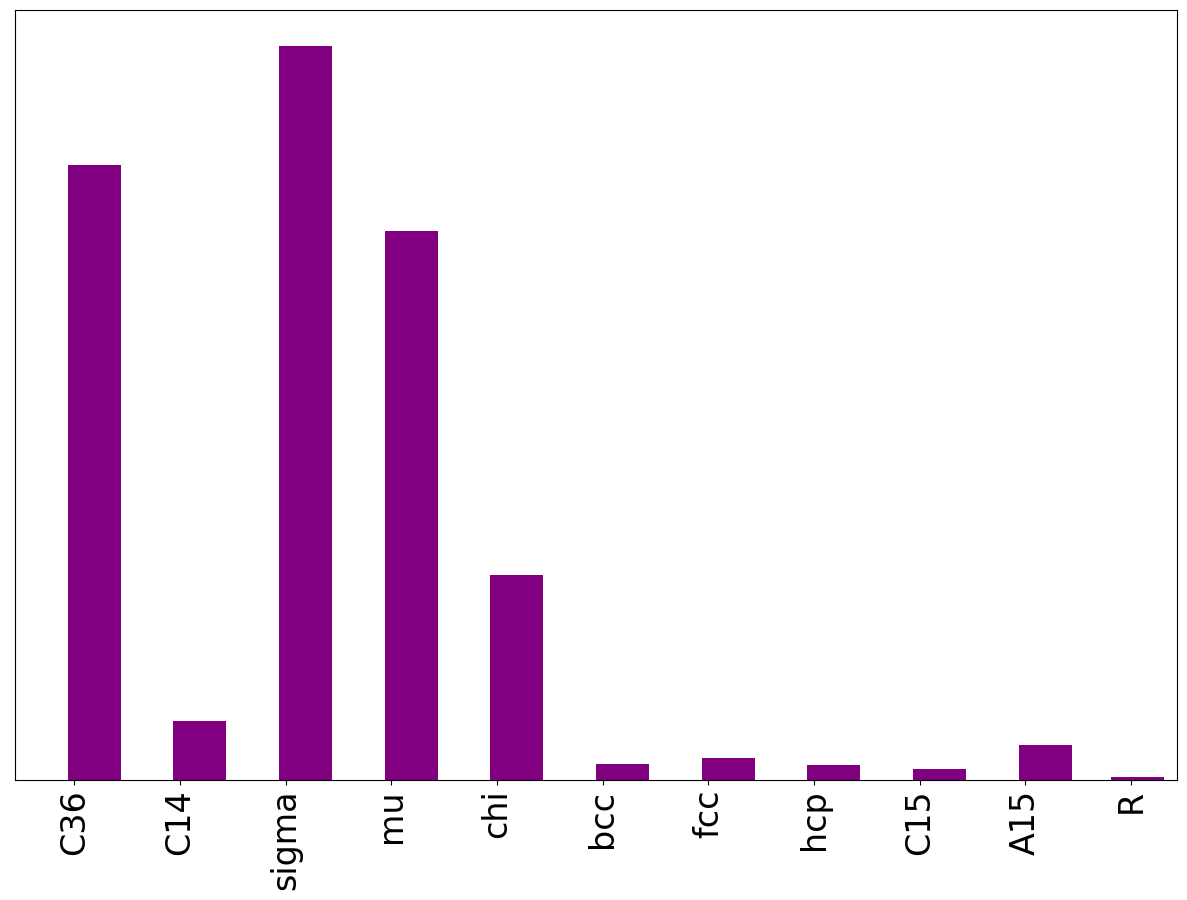

In [33]:
from BopFoxFeaturizer.struct_db import struct_db
#struct_db = SourceFileLoader('struct_db','BopFoxFeaturizer/struct_db.py').load_module().struct_db
strucdic = struct_db().strucstrings

Target_Class = pd.Series(
    DATA.index.str.split('.').map(lambda l: l[1]).map(lambda s: s.split('-')[0]),
    index=DATA.index
)
Target_Class[Target_Class.map(lambda s: s in strucdic['list.hcp'])]='hcp'
Target_Class[Target_Class.map(lambda s: s in strucdic['list.fcc'])]='fcc'
Target_Class[Target_Class.map(lambda s: s in strucdic['list.bcc'])]='bcc'
Target_Class[Features.Struc == 'hcp'] = 'hcp'
Target_Class[Features.Struc == 'bcc'] = 'bcc'
Target_Class[Features.Struc == 'fcc'] = 'fcc'
Target_Class[Features.Struc.str.contains('SQS-fcc')] = 'fcc'
Target_Class[Features.Struc.str.contains('SQS-L12')] = 'fcc'
Target_Class[Features.Struc.str.contains('sigma_')] = 'sigma'

Target_Class[    
    Target_Class.str.contains('Al42W') |\
    Target_Class.str.contains('Al9Co2') |\
    Target_Class.str.contains('Al5W') |\
    Target_Class.str.contains('Al12W') |\
    Target_Class.str.contains('Al4W') |\
    Target_Class.str.contains('Al5Co2')
] = 'others'

plt.hist(Target_Class, bins=80, density = True, width=0.5, align='left', color = 'purple')
plt.xticks(rotation=90); yticks = plt.yticks([])
plt.ylabel('')

## Class Weights

In [34]:
Classes = pd.DataFrame(Target_Class.values, columns=['Class'], index=DATA.index)
Target_Class_Count = Target_Class.value_counts()
Classes['Weights'] = 1/(Target_Class_Count[Target_Class]/Target_Class_Count.sum()).values #Target_Class_Count.sum()

In [35]:
data_w_classes =pd.concat([DATA,Classes['Class'].loc[DATA.index]], axis=1) 

## Remove C14!

DATA = DATA[data_w_classes['Class']!='C14']
Classes = Classes[Classes['Class']!='C14']

# Finally some Machine Learning

[![scikit-logo](https://scikit-learn.org/stable/_static/scikit-learn-logo-small.png#background-color:"#FFFFFF")](https://scikit-learn.org/stable/) is a standard tool for machine learning in python. The documentation in their webpage is often a good refference for tutorials, methods and Theory of Machine Learning. 

In [36]:
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from math import sqrt
from sklearn.metrics import r2_score
from sklearn.pipeline import Pipeline
from sklearn.svm import SVR
from sklearn.inspection import permutation_importance
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import Lasso

## Feature Selection 

In [37]:
from sklearn.feature_selection import  (
    RFECV, 
    SelectKBest, 
    SequentialFeatureSelector,
    mutual_info_regression
)

In [38]:
from sklearn.model_selection import GridSearchCV

## Helper Functions

In [40]:
def plot_the_errors(THISERRORS,thecase):
    alltheclases = np.unique(Classes['Class'])
    thebadclasses = ['hcp', 'bcc', 'fcc','others','delta','R','C15']
    thegoodclases = [c for c in alltheclases if c not in thebadclasses ]
    fig, ax = plt.subplots(len(thegoodclases),1, sharex=True, figsize =(10,2*len(thegoodclases)))
    for i, classes in enumerate(thegoodclases) :
        thiserrors = np.abs(THISERRORS[Classes['Class']==classes])
        e = ax[i].hist (thiserrors, density=False, bins=100, label=classes)
        ax[i].annotate(classes, (0.8,0.5),xycoords = 'axes fraction', fontsize=20)
#    ax[-1].set_xlim([-0.01,1.0])
    ax[-1].set_ylabel('Density Counts',y=4), plt.xlabel('$|  Target^{predicted} -  Target^{True} | $')
    fig.tight_layout()
    fig.savefig(FileNames.get_plot_filename('Errors_by_class', thecase))
#    fig.savefig('graphs/Errors_by_class_{}_{}_{}_{}.pdf'.format(case, CASE, MODEL, CUTOFF))
    

def plot_the_prediction_line(theprediction, thepredictionovertest, thecase):
    fig, ax = plt.subplots()
    ax.plot(theprediction, DATA[TARGET],'o', label='full dataset')
    ax.plot(thepredictionovertest, Y_test,'o', label='test set')
    ax.plot(DATA[TARGET], DATA[TARGET],'-k')
    ax.legend()
    ax.set_xlabel('True')# $\Delta E_F$')
    ax.set_ylabel('predicted')# $\Delta E_F$')
    fig.savefig(FileNames.get_plot_filename('Predictionline',thecase))
#    fig.savefig('graphs/predictionline_{}_{}.pdf'.format(themodel,CASE, MODEL, CUTOFF))

def train_test_errors(themodel, Xtrain, Xtest, Ytrain, Ytest):
    Ypredict_train = themodel.predict(Xtrain)
    Ypredict_test = themodel.predict(Xtest)
    return {'train': mean_squared_error(Ytrain, Ypredict_train ,squared=False), 'test':  mean_squared_error(Ytest, Ypredict_test,squared=False )}

def make_simple_pipe(model, with_scaler = True):
        if with_scaler:
            return Pipeline([('scaler',MinMaxScaler()),('regressor', model())])
        else:
            return Pipeline([('regressor', model())])

# Train test split 

In [41]:
X_train, X_test, w_train, w_test,  Y_train, Y_test = train_test_split(DATA[real_feature],Classes['Weights'], DATA[TARGET],test_size=0.2, shuffle=True)

I need Lists of errors to compare methods

In [42]:
mses = {}

I also need to remove targets from feature names

## simple regressor - random forest

In [43]:
simple_model = make_simple_pipe(RandomForestRegressor)

In [44]:
simple_model.fit(X_train,Y_train)

Pipeline(steps=[('scaler', MinMaxScaler()),
                ('regressor', RandomForestRegressor())])

In [45]:
mses['random forest regressor'] = train_test_errors(simple_model, X_train, X_test,Y_train, Y_test)

In [46]:
mses

{'random forest regressor': {'train': 0.047200178603115865,
  'test': 0.0841968510196309}}

In [47]:
simple_model_noscaler = make_simple_pipe(RandomForestRegressor, with_scaler=False)

In [48]:
simple_model_noscaler.fit(X_train, Y_train)

Pipeline(steps=[('regressor', RandomForestRegressor())])

In [49]:
mses['random forest regressor noscale'] = train_test_errors(simple_model_noscaler, X_train, X_test, Y_train, Y_test)

In [50]:
mses

{'random forest regressor': {'train': 0.047200178603115865,
  'test': 0.0841968510196309},
 'random forest regressor noscale': {'train': 0.04750787101858915,
  'test': 0.0847203960053568}}

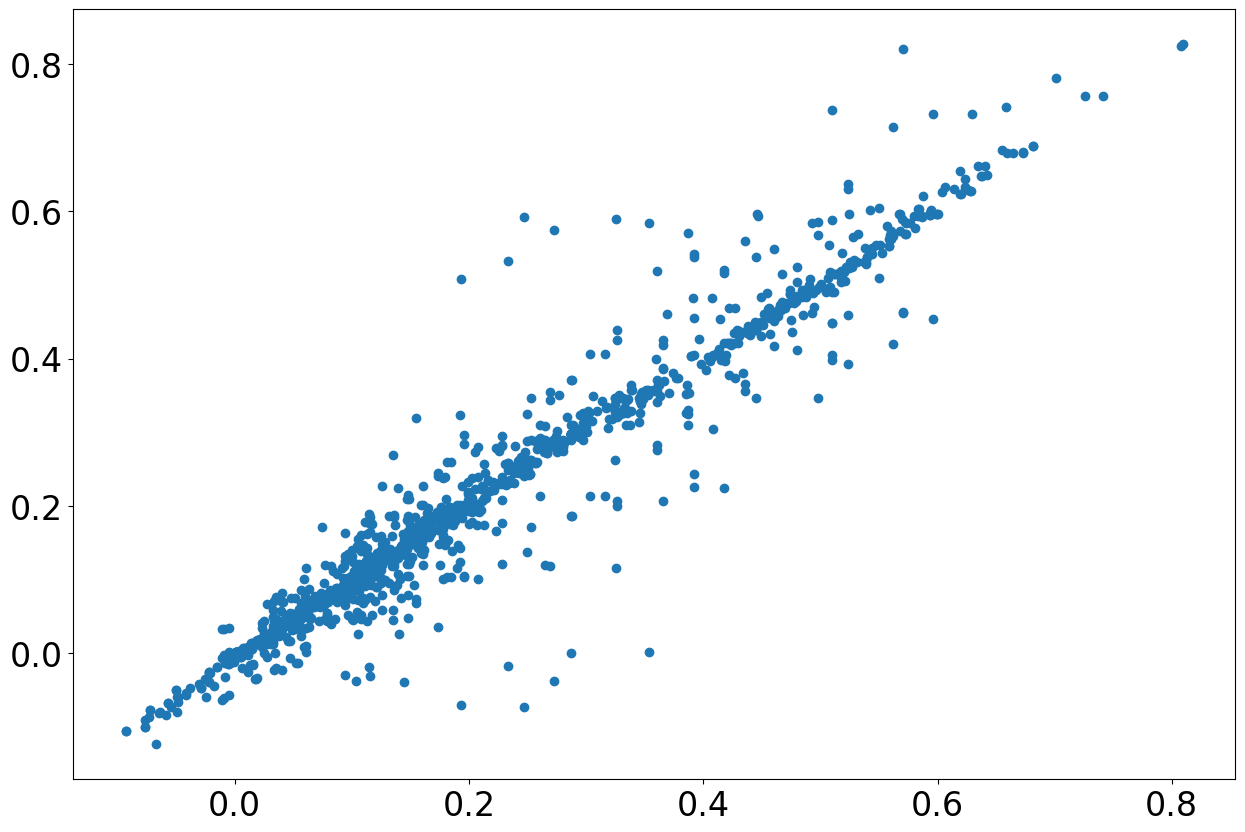

In [51]:
plt.plot(simple_model.predict(X_train),Y_train,'o')
#plt.plot(simple_model_noscaler.predict(X_train),Y_train,'o')

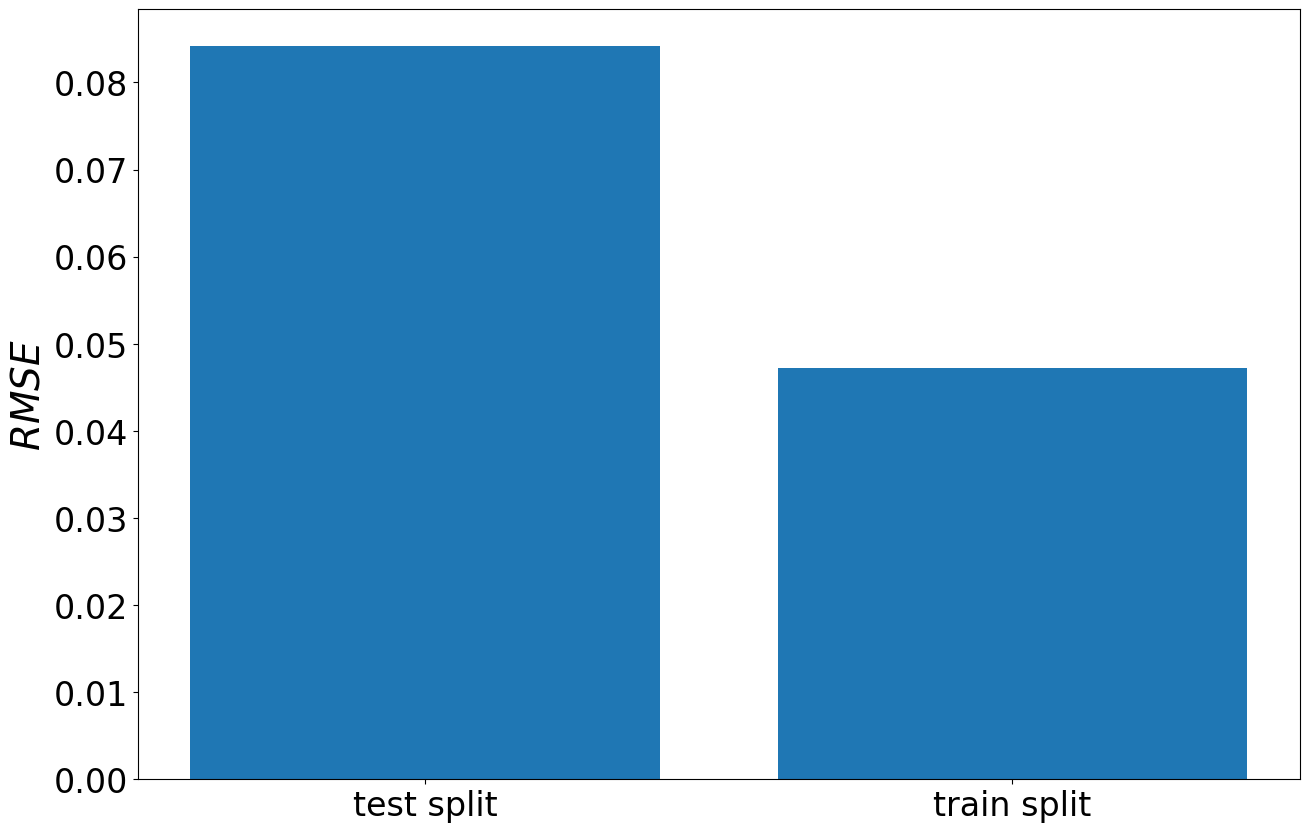

In [52]:
plt.bar(['test split','train split'],[mses['random forest regressor']['test'], mses['random forest regressor']['train']])
label = plt.ylabel('$RMSE$')

In [53]:
YPREDICT = simple_model.predict(DATA[real_feature])
Y_predict_test = simple_model.predict(X_test)
ERRORS = (YPREDICT - DATA[TARGET]).map(np.abs)

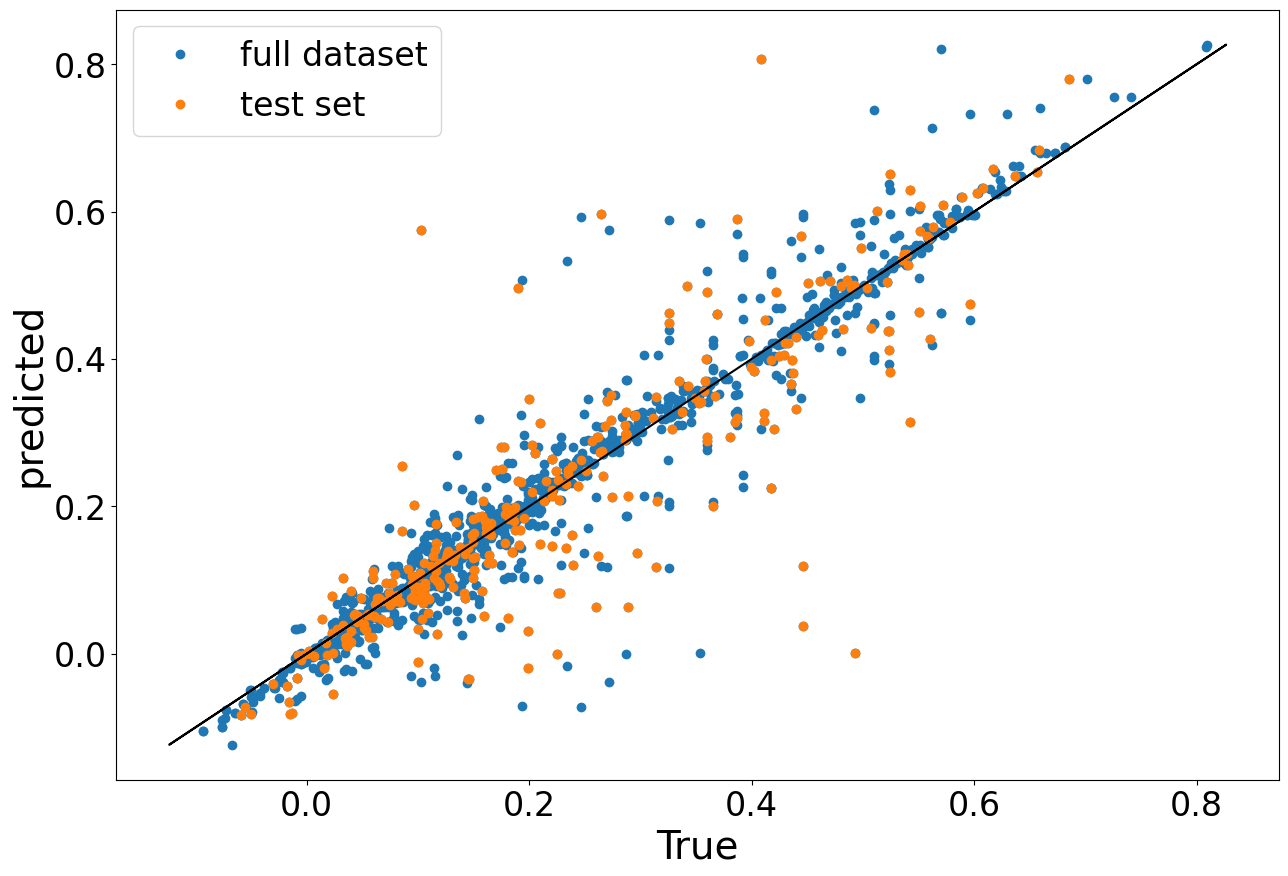

In [54]:
plot_the_prediction_line(YPREDICT, Y_predict_test, 'RandomForestRegressor')

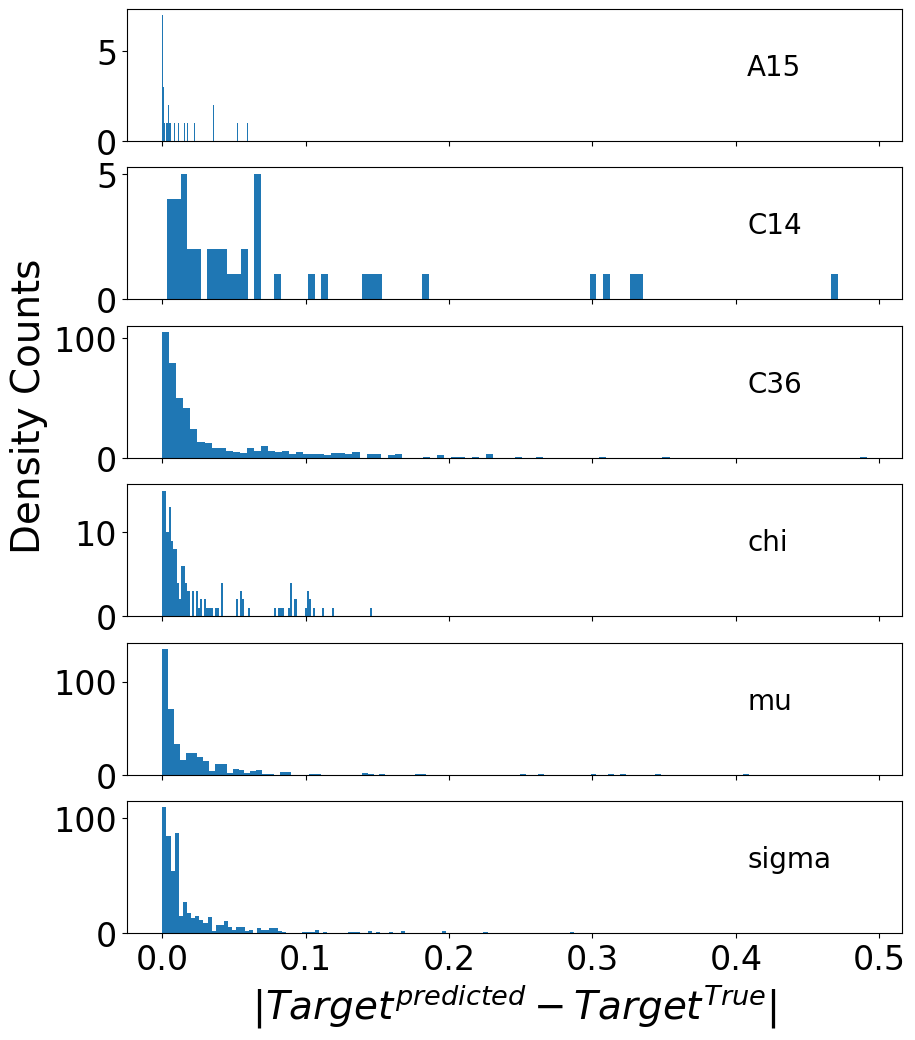

In [55]:
plot_the_errors(ERRORS,'RandomForestRegressor')

In [180]:
ERRORS[(ERRORS > 0.15) & ERRORS.index.str.contains('C36')]

Co_pv10W_sv14.C36-BBAAB.FM    0.192538
Co_pv10W_sv14.C36-BBAAB.NM    0.166294
Co_pv10W_sv14.C36-BBABA.FM    0.193446
Co_pv12W_sv12.C36-AAABB.NM    0.230541
Co_pv12W_sv12.C36-BBBAA.FM    0.491313
Co_pv12W_sv12.C36-BBBAA.NM    0.352441
Co_pv14W_sv10.C36-AABAB.NM    0.227787
Co_pv4W_sv20.C36-BBABB.NM     0.227765
Co_pv8W_sv16.C36-AABBB.NM     0.249823
Cr_pv10W_sv14.C36-BBAAB.FM    0.159203
Cr_pv10W_sv14.C36-BBABA.FM    0.165441
Cr_pv12W_sv12.C36-AAABB.FM    0.307100
Cr_pv12W_sv12.C36-AAABB.NM    0.262829
Cr_pv12W_sv12.C36-BBBAA.NM    0.209985
Cr_pv14W_sv10.C36-AABAB.FM    0.158753
Cr_pv14W_sv10.C36-AABAB.NM    0.203826
Cr_pv14W_sv10.C36-AABBA.NM    0.183160
Cr_pv16W_sv8.C36-BBAAA.NM     0.218011
Cr_pv20W_sv4.C36-AABAA.NM     0.164007
Cr_pv4W_sv20.C36-BBABB.NM     0.150810
Name: EF, dtype: float64

Now I will use this vlolume to try to target the formation energy

DATA['VP'] = simple_model.predict(DATA[real_feature])

intermediate_feature = ['VP']

model_formation_energy = RandomForestRegressor()

X_train_ef, X_test_ef , Y_train_ef, Y_test_ef = train_test_split(DATA[real_feature+intermediate_feature], DATA['EF'])

model_formation_energy.fit(X_train_ef, Y_train_ef)

mses['model_formation_energy'] = {
    'test': mean_squared_error(Y_test_ef, model_formation_energy.predict(X_test_ef), squared=False),
    'train': mean_squared_error(Y_train_ef, model_formation_energy.predict(X_train_ef), squared=False)
}

In [61]:
mses

{'random forest regressor': {'train': 0.047200178603115865,
  'test': 0.0841968510196309},
 'random forest regressor noscale': {'train': 0.04750787101858915,
  'test': 0.0847203960053568}}

There is a big variety of regression methods available in scikit-learn package.
[See the documentation](https://scikit-learn.org/stable/supervised_learning.html#supervised-learninghttps://scikit-learn.org/stable/supervised_learning.html#supervised-learning)

# Feature Selection

## Random Forest + selectkbest

In [62]:
useful_feature = []
for key in useful.keys():
    useful_feature+=useful[key]

In [63]:
Selector = SelectKBest(mutual_info_regression, k=15)
Selector.fit(X_train[useful_feature], Y_train)

SelectKBest(k=15,
            score_func=<function mutual_info_regression at 0x7ffa0576b700>)

In [64]:
simple_model = RandomForestRegressor()

In [65]:
np.array(useful_feature)[Selector.get_support()]

array(['all_NSC_an_4', 'all_NSC_an_5', 'all_NSC_bn_2', 'all_NSC_bn_5',
       'all_NSC_bn_6', 'all_NSC_bn_7', 'CN12_NSC_bn_5', 'CN12_NSC_bn_6',
       'all_NSC_moments_5', 'all_NSC_moments_6', 'all_NSC_moments_7',
       'all_NSC_moments_8', 'all_NSC_moments_9', 'all_NSC_moments_10',
       'all_NSC_moments_11'], dtype='<U22')

In [66]:
simple_model.fit(X_train[np.array(useful_feature)[Selector.get_support()]], Y_train)

RandomForestRegressor()

In [67]:
Y_predict = simple_model.predict(X_train[np.array(useful_feature)[Selector.get_support()]])

mses['simplekbest'] = {'train': mean_squared_error(Y_train, Y_predict, squared=False)}

Y_test_predict = simple_model.predict(X_test[np.array(useful_feature)[Selector.get_support()]])

mses['simplekbest'].update({'test': mean_squared_error(Y_test, Y_test_predict,squared=False)})

In [68]:
mses

{'random forest regressor': {'train': 0.047200178603115865,
  'test': 0.0841968510196309},
 'random forest regressor noscale': {'train': 0.04750787101858915,
  'test': 0.0847203960053568},
 'simplekbest': {'train': 0.0518083710135853, 'test': 0.07854999227828703}}

### on a pipeline

In [78]:
RF_SelectKbest = Pipeline(
    [
        ('feature_selection', SelectKBest(k=15)),
        ('regression', RandomForestRegressor())
    ]
)

In [79]:
RF_SelectKbest.fit(X_train, Y_train)

Pipeline(steps=[('feature_selection', SelectKBest(k=15)),
                ('regression', RandomForestRegressor())])

In [80]:
Y_predict_Pipe  = RF_SelectKbest.predict(X_train)

mses['RF_SK_Pipe'] = {'train': mean_squared_error(Y_train, Y_predict_Pipe, squared=False) }

Y_test_predict_Pipe = RF_SelectKbest.predict(X_test)

mses['RF_SK_Pipe'].update({'test': mean_squared_error(Y_test, Y_test_predict_Pipe, squared=False)})

In [81]:
np.array(real_feature)[RF_SelectKbest[0].get_support()]

array(['atom_A_W_sv', 'atom_B_', 'atom_B_Co_pv', 'atom_B_W_sv', 'atom_C_',
       'atom_C_W_sv', 'avg_dev NdUnfilled', 'range NUnfilled',
       'avg_dev NUnfilled', 'range GSvolume_pa', 'avg_dev GSvolume_pa',
       'range GSmagmom', 'avg_dev GSmagmom', 'range SpaceGroupNumber',
       'avg_dev SpaceGroupNumber'], dtype='<U27')

In [82]:
mses

{'random forest regressor': {'train': 0.047200178603115865,
  'test': 0.0841968510196309},
 'random forest regressor noscale': {'train': 0.04750787101858915,
  'test': 0.0847203960053568},
 'simplekbest': {'train': 0.0518083710135853, 'test': 0.07854999227828703},
 'RF_SK_Pipe': {'train': 0.09761109070281283, 'test': 0.12170959177607699}}

### with cross validation

In [86]:
Params= {'feature_selection__k':np.arange(15,25), 'regression__max_depth':np.arange(20,30)} #,1, 2,3,4,5,6,7,8,9]} #, 'regression__alpha':[0.01, 0.1,1]}

In [87]:
Validator = GridSearchCV(RF_SelectKbest,Params, refit=True, scoring='neg_root_mean_squared_error',verbose=5,n_jobs=3)

In [88]:
Validator.fit(X_train, Y_train)

Fitting 5 folds for each of 100 candidates, totalling 500 fits


GridSearchCV(estimator=Pipeline(steps=[('feature_selection', SelectKBest(k=15)),
                                       ('regression',
                                        RandomForestRegressor())]),
             n_jobs=3,
             param_grid={'feature_selection__k': array([15, 16, 17, 18, 19, 20, 21, 22, 23, 24]),
                         'regression__max_depth': array([20, 21, 22, 23, 24, 25, 26, 27, 28, 29])},
             scoring='neg_root_mean_squared_error', verbose=5)

In [89]:
Validator.best_estimator_

Pipeline(steps=[('feature_selection', SelectKBest(k=24)),
                ('regression', RandomForestRegressor(max_depth=24))])

In [ ]:
fitted_best_estimator = Validator.best_estimator_.fit(X_train, Y_train)

In [90]:
x = Validator.cv_results_['param_feature_selection__k'].data

In [91]:
y = Validator.cv_results_['mean_test_score']

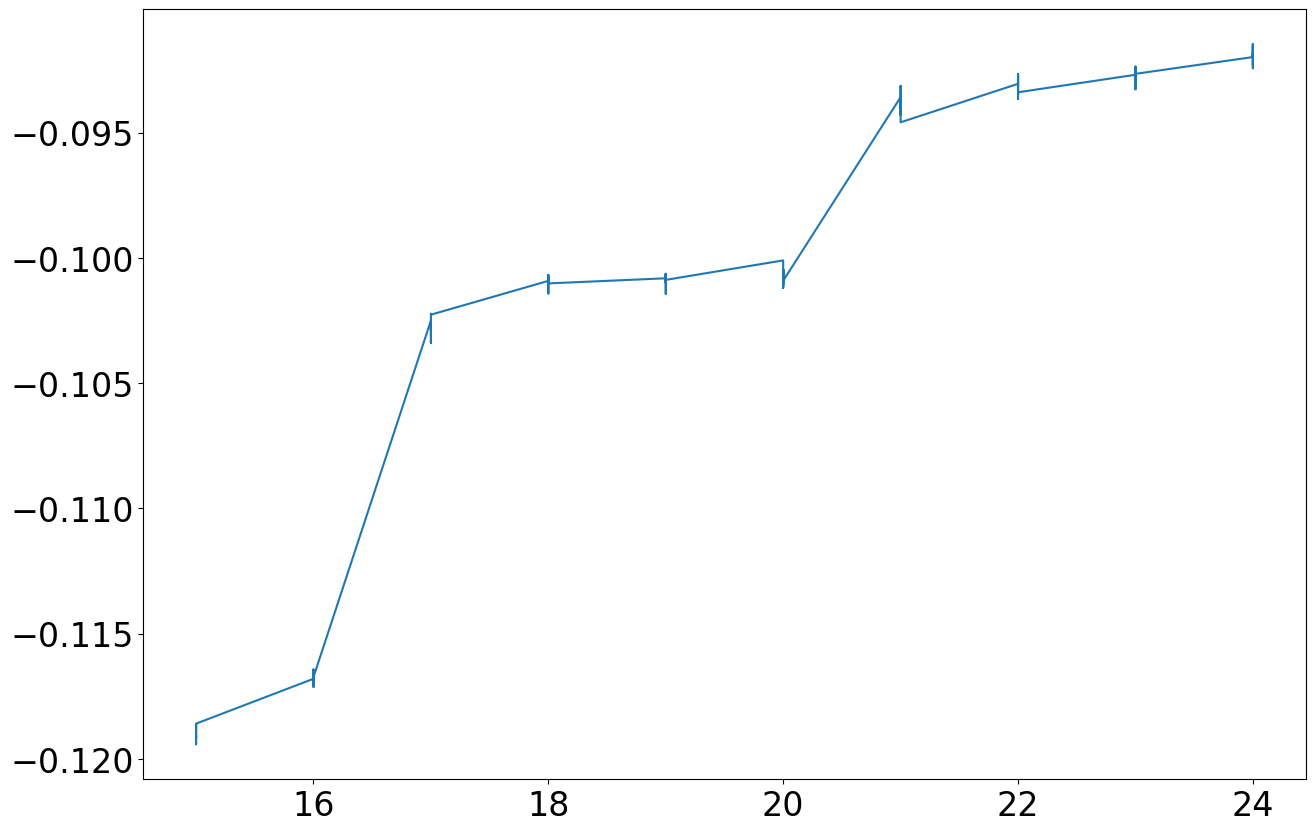

In [92]:
plt.plot(x,y)

In [94]:
X_train.columns[Validator.best_estimator_[0].get_support()]

Index(['CN16_NSC_SIGMA_11', 'CN16_NSC_SIGMA_12', 'CN16_NSC_SIGMA_13',
       'CN16_NSC_SIGMA_14', 'CN13_NSC_Ainf_0', 'CN16_NSC_Ainf_0',
       'CN13_NSC_Binf_0', 'CN16_NSC_Binf_0', 'W_sv', 'atom_A_W_sv', 'atom_B_',
       'atom_B_Co_pv', 'atom_B_W_sv', 'atom_C_', 'atom_C_W_sv',
       'avg_dev NdUnfilled', 'range NUnfilled', 'avg_dev NUnfilled',
       'range GSvolume_pa', 'avg_dev GSvolume_pa', 'range GSmagmom',
       'avg_dev GSmagmom', 'range SpaceGroupNumber',
       'avg_dev SpaceGroupNumber'],
      dtype='object')

## just in a loop

In [ ]:
RF_SelectKbest

In [ ]:
for k in range(20,30):
#    model = Pipeline([
#        ('feature_selection', SelectKBest(k=k)),
#        ('regression', RandomForestRegressor(max_depth=20))
#    ])
    Params = {'feature_selection__k': [k]}
    model = GridSearchCV(RF_SelectKbest,param_grid=Params,scoring='neg_root_mean_squared_error')
    model.fit(X_train, Y_train)
    mask = model.best_estimator_[0].get_support()
    importances = model.best_estimator_[1].feature_importances_
    print(k, np.array(real_feature)[mask][:3], importances[:3], model.cv_results_['mean_test_score'])
#    print(k, real_feature[model[0].get_support()])

In [ ]:
Y_test_predict = fitted_best_estimator.predict(X_test)

Y_train_predict = fitted_best_estimator.predict(X_train)

mses['RF_SK_pipe'] ={'test':mean_squared_error(Y_test, Y_test_predict,squared=False)}

mses['RF_SK_pipe'].update({'train':mean_squared_error(Y_train, Y_train_predict, squared=False)})

In [ ]:
mses

## Ranod Forest + Sequential Selection

This is the same as the FeatureConcatenation I implemented, but the output doesnt tell which feature is most important and doesnt let you fix any feature

In [ ]:
SeqSelector = SequentialFeatureSelector(
    RandomForestRegressor(),
    n_features_to_select=10, n_jobs=3, 
    scoring='neg_root_mean_squared_error')

In [ ]:
SeqSelector.fit(X_train, Y_train)

In [ ]:
SeqSelector

In [ ]:
X_train.columns[SeqSelector.get_support()]

In [ ]:
features = X_train.columns[SeqSelector.get_support()]

In [ ]:
features

In [ ]:
allfeatures = features.append( pd.Index(['MagConfig_0']))

In [ ]:
allfeatures

In [ ]:
model = RandomForestRegressor(max_depth=20)

In [ ]:
model.fit(X_train[features], Y_train)

In [ ]:
mses['RF_After_SeqSelection'] = {
    'test': mean_squared_error(Y_test, model.predict(X_test[allfeatures]),squared=False),
    'train': mean_squared_error(Y_train, model.predict(X_train[allfeatures]),squared=False)
}

In [ ]:
mses

In [ ]:
model.feature_importances_

In [ ]:
fig, ax = plt.subplots()
ax.plot( model.feature_importances_, features,)
labels = ax.get_xticklabels()
ax.grid('on')
#ax.set_xticklabels(labels, rotation=90)
#fig.tight_layout()

## Random Forest + recursive feature elumination with CV

In [95]:
Selector = RFECV (RandomForestRegressor(), min_features_to_select=10, 
                 scoring='neg_root_mean_squared_error', verbose=5, n_jobs=3)

In [96]:
Selector.fit(X_train, Y_train)

Fitting estimator with 315 features.
Fitting estimator with 314 features.
Fitting estimator with 313 features.
Fitting estimator with 312 features.
Fitting estimator with 311 features.
Fitting estimator with 310 features.
Fitting estimator with 309 features.
Fitting estimator with 308 features.
Fitting estimator with 307 features.
Fitting estimator with 306 features.
Fitting estimator with 305 features.
Fitting estimator with 304 features.
Fitting estimator with 303 features.
Fitting estimator with 302 features.
Fitting estimator with 301 features.
Fitting estimator with 300 features.
Fitting estimator with 299 features.
Fitting estimator with 298 features.
Fitting estimator with 297 features.
Fitting estimator with 296 features.
Fitting estimator with 295 features.
Fitting estimator with 294 features.
Fitting estimator with 293 features.
Fitting estimator with 292 features.
Fitting estimator with 291 features.
Fitting estimator with 290 features.
Fitting estimator with 289 features.
F

RFECV(estimator=RandomForestRegressor(), min_features_to_select=10, n_jobs=3,
      scoring='neg_root_mean_squared_error', verbose=5)

In [97]:
import joblib

In [98]:
joblib.dump(Selector, 'SelectorRFECV')

['SelectorRFECV']

In [100]:
X_train.columns[Selector.support_]

Index(['all_NSC_U_bond_atom_0', 'all_NSC_moments_2', 'all_NSC_moments_5',
       'CN12_NSC_moments_3', 'all_NSC_an_4', 'all_NSC_an_6', 'CN12_NSC_an_2',
       'CN12_NSC_an_3', 'all_NSC_bn_2', 'all_NSC_bn_4', 'CN16_NSC_bn_4',
       'CN16_NSC_bn_5', 'all_NSC_SIGMA_6', 'all_NSC_SIGMA_8',
       'all_NSC_SIGMA_9', 'all_NSC_SIGMA_11', 'all_NSC_SIGMA_13',
       'CN12_NSC_SIGMA_5', 'CN12_NSC_SIGMA_6', 'CN12_NSC_SIGMA_9',
       'CN16_NSC_SIGMA_2', 'all_NSC_Binf_0', 'Co_pv', 'W_sv',
       'avg_dev GSvolume_pa'],
      dtype='object')

In [112]:
Selector.grid_scores_.shape

(306, 5)

In [114]:
Selector.get_feature_names_out()

array(['all_NSC_U_bond_atom_0', 'all_NSC_moments_2', 'all_NSC_moments_5',
       'CN12_NSC_moments_3', 'all_NSC_an_4', 'all_NSC_an_6',
       'CN12_NSC_an_2', 'CN12_NSC_an_3', 'all_NSC_bn_2', 'all_NSC_bn_4',
       'CN16_NSC_bn_4', 'CN16_NSC_bn_5', 'all_NSC_SIGMA_6',
       'all_NSC_SIGMA_8', 'all_NSC_SIGMA_9', 'all_NSC_SIGMA_11',
       'all_NSC_SIGMA_13', 'CN12_NSC_SIGMA_5', 'CN12_NSC_SIGMA_6',
       'CN12_NSC_SIGMA_9', 'CN16_NSC_SIGMA_2', 'all_NSC_Binf_0', 'Co_pv',
       'W_sv', 'avg_dev GSvolume_pa'], dtype=object)

In [115]:
Selector.estimator_.feature_importances_

array([0.01419612, 0.01049602, 0.01461983, 0.01477714, 0.01328481,
       0.01345732, 0.01139155, 0.01194581, 0.04787679, 0.04419046,
       0.44975916, 0.16564687, 0.01052905, 0.01606706, 0.01433995,
       0.01000108, 0.01282915, 0.01045596, 0.0147049 , 0.01305286,
       0.0211701 , 0.0134874 , 0.02306584, 0.01401577, 0.01463899])

<BarContainer object of 25 artists>

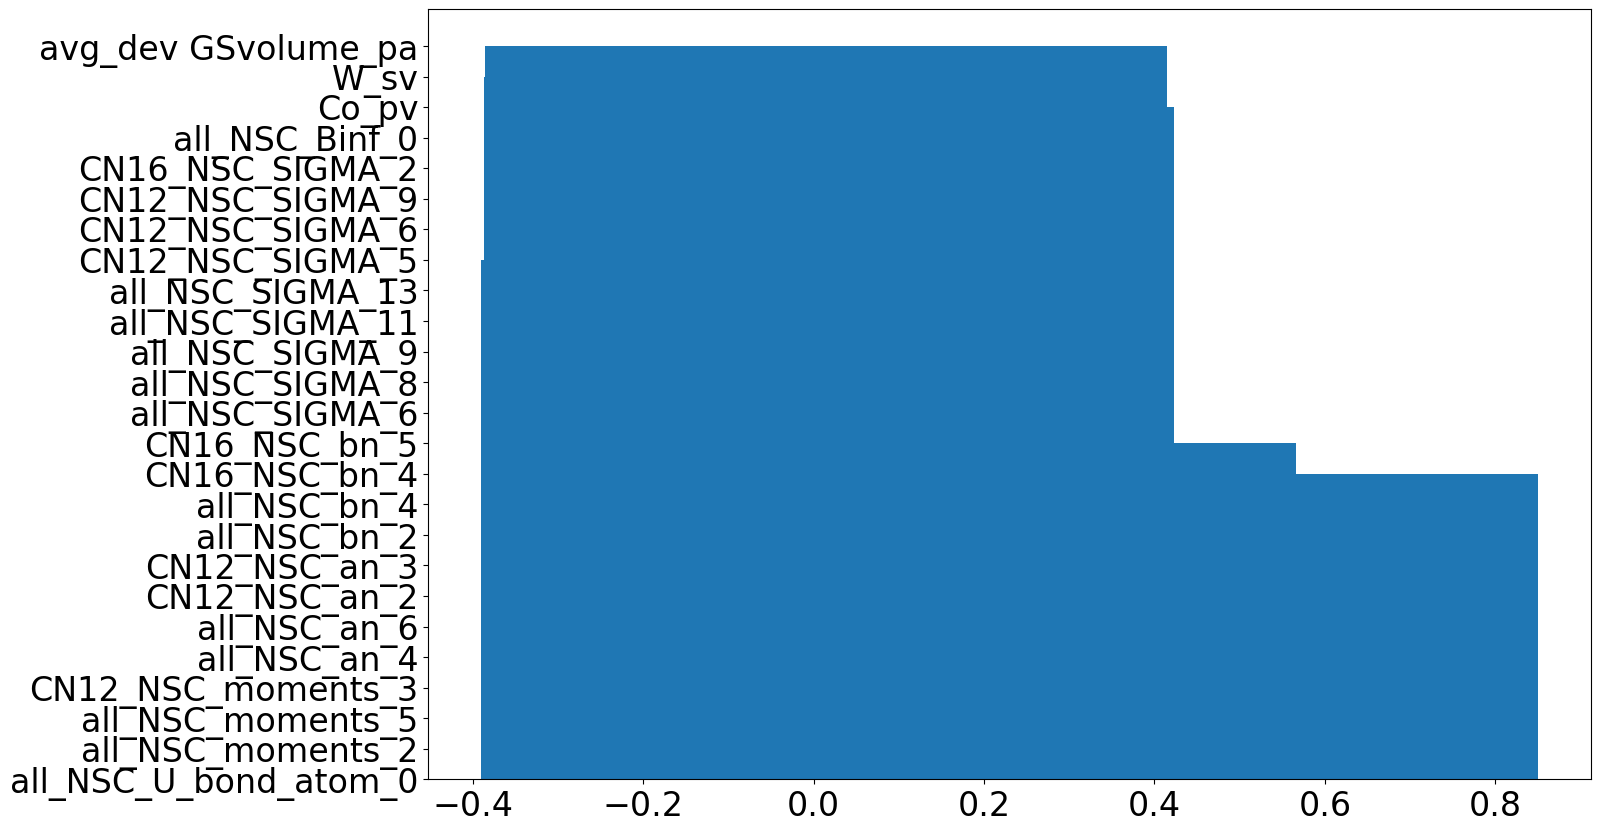

In [117]:
plt.bar(Selector.estimator_.feature_importances_, Selector.get_feature_names_out())


In [142]:
rankings = np.unique(Selector.ranking_)

In [ ]:
for rank in rankings:
    print(rank, Selector.feature_names_in_[Selector.ranking_ == rank])

In [151]:
Selector.cv_results_['mean_test_score'][1]

-0.08465598264467852

In [154]:
Selector.cv_results_.keys()

dict_keys(['mean_test_score', 'std_test_score', 'split0_test_score', 'split1_test_score', 'split2_test_score', 'split3_test_score', 'split4_test_score'])

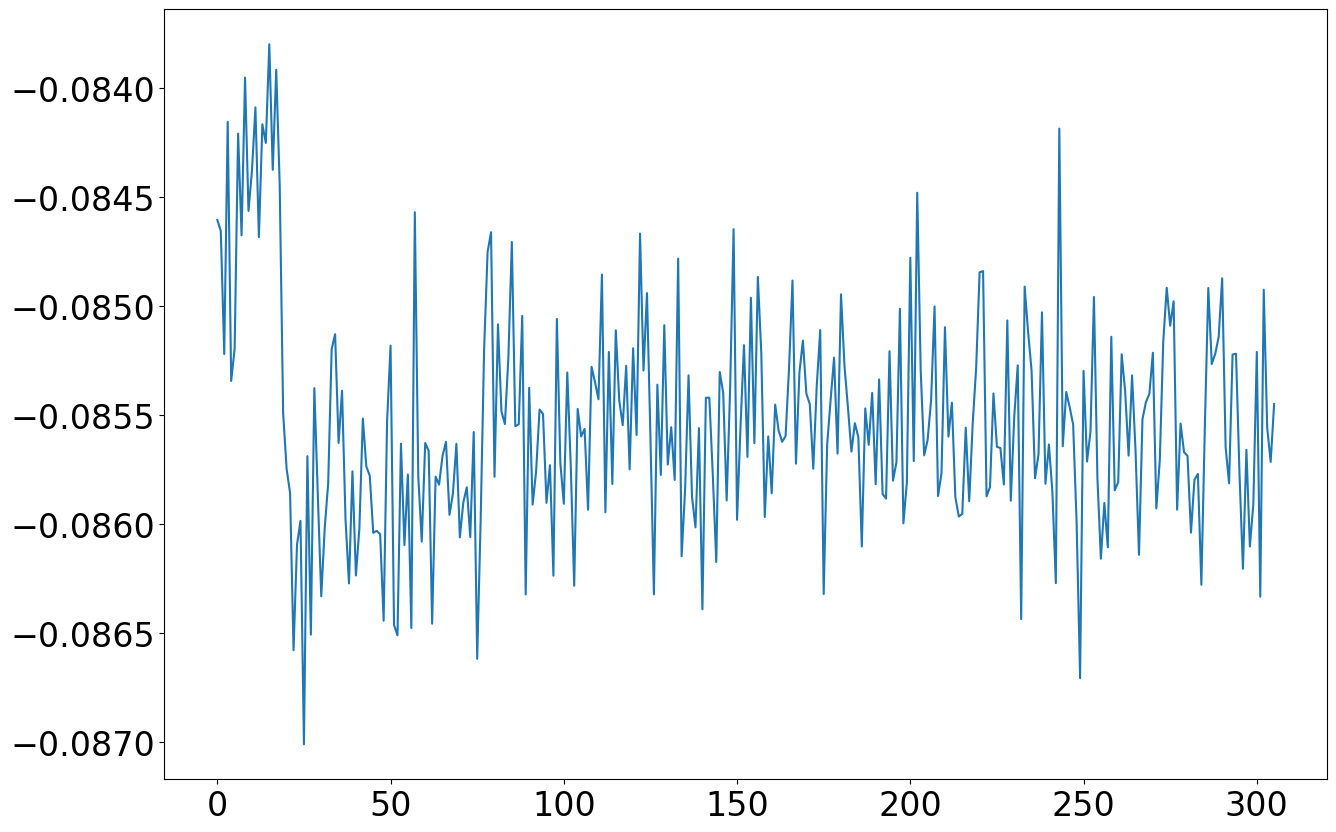

In [153]:
plt.plot(Selector.cv_results_[''])

# My Old Feature Concatenation 

In [160]:
FC = {}

In [161]:
# This is the standard way to import modules
del FeatureConcatenate
# from BopFoxFeaturizer.FeatureConcatenate import FeatureConcatenate
FeatureConcatenate = SourceFileLoader('FeatureConcate','/home/storage/fortimtb/CuadernoTrabajo/bopfoxfeaturizer/BopFoxFeaturizer/FeatureConcatenate.py'
                                     ).load_module().FeatureConcatenate

In [163]:
#param_grid = {'max_depth':np.arange(1,10) , 'min_samples_split':[2]}
param_grid = {}
FC['RandomForest'] = FeatureConcatenate(
    #pd.concat([X_train, Y_train['EF']], axis=1), #DATA, 
    DATA[real_feature+[TARGET]],
    RandomForestRegressor(),
    model_params=param_grid,
    feature_list=real_feature,
    data_target=TARGET,
    criterion = C_RITERION,
    sort_criteria='score_only'
#    sample_weights = w_train, #Classes['Weights']
)

In [164]:
Bestfeats={}
Bestscores={}

In [163]:
Bestfeats['RandomForest'], Bestscores['RandomForest'] = FC['RandomForest'].build_features_list(
    best_feature_proposal=['MagConfig'],  #,'NSC_U_bind_0'],
    maxnumfeatures=10,
    pass_force_refit=True,
    report_prefix='RandomForest_W_CNAV'+CASE
)

procesing '[]' with 'MagConfig' ... ::   0%|                                                      | 0/1 [00:00<?, ?it/s]

Refitting ..


procesing '[]' with 'MagConfig' ... :: 100%|##############################################| 1/1 [00:00<00:00,  1.47it/s]
procesing '['MagConfig']' with 'CN15_NSC_SIGMA_2' ... ::   0%|                                  | 0/314 [00:00<?, ?it/s]

fitting has finished,  test_score  =  0.18608860088407142
Refitting ..


procesing '['MagConfig']' with 'CN15_NSC_SIGMA_13' ... :: 100%|#######################| 314/314 [05:23<00:00,  1.03s/it]


...

procesing '['MagConfig', 'CN12_NSC_bn_4', 'all_NSC_moments_8', 'CN16_NSC_an_6', 'all_NSC_SIGMA_12', 'CN13_NSC_moments_6'

Refitting ..


procesing '['MagConfig', 'CN12_NSC_bn_4', 'all_NSC_moments_8', 'CN16_NSC_an_6', 'all_NSC_SIGMA_12', 'CN13_NSC_moments_6'


fitting has finished,  test_score  =  0.0866134539571907


NameError: name 'Bestfeats' is not defined

In [174]:
first_report = pd.read_pickle('reports/RandomForest_W_CNAVINITIALreport_1.csv')

In [175]:
first_report

,best_estimator,best_score,error,test_score,train_score
CN12_NSC_bn_4,"(DecisionTreeRegressor(max_features='auto', ra...",0.013991,0.074968,0.111180,0.062689
all_NSC_bn_2,"(DecisionTreeRegressor(max_features='auto', ra...",0.013088,0.069630,0.111455,0.054306
all_NSC_moments_10,"(DecisionTreeRegressor(max_features='auto', ra...",0.014253,0.070556,0.112147,0.055433
CN16_NSC_bn_7,"(DecisionTreeRegressor(max_features='auto', ra...",0.014455,0.090558,0.112411,0.084194
all_NSC_moments_8,"(DecisionTreeRegressor(max_features='auto', ra...",0.012406,0.069504,0.112496,0.053561
...,...,...,...,...,...
CN12_NSC_SIGMA_0,"(DecisionTreeRegressor(max_features='auto', ra...",0.035293,0.187148,0.186565,0.187294
atom_A_Co_pv,"(DecisionTreeRegressor(max_features='auto', ra...",0.034853,0.186243,0.186565,0.186163
CN13_NSC_SIGMA_0,"(DecisionTreeRegressor(max_features='auto', ra...",0.035263,0.187166,0.186637,0.187298
atom_A_Cr_pv,"(DecisionTreeRegressor(max_features='auto', ra...",0.034840,0.186213,0.186662,0.186101


In [173]:
FC['RandomForest'].report

,best_estimator,best_score,error,test_score,train_score
CN14_NSC_SIGMA_5,"(DecisionTreeRegressor(max_features='auto', ra...",0.007651,0.057219,0.083421,0.048477
CN14_NSC_SIGMA_8,"(DecisionTreeRegressor(max_features='auto', ra...",0.007650,0.057056,0.083884,0.048035
CN15_NSC_moments_3,"(DecisionTreeRegressor(max_features='auto', ra...",0.007616,0.057388,0.084022,0.048466
CN15_NSC_SIGMA_4,"(DecisionTreeRegressor(max_features='auto', ra...",0.007703,0.057388,0.084436,0.048286
CN15_NSC_moments_1,"(DecisionTreeRegressor(max_features='auto', ra...",0.007596,0.057410,0.084556,0.048266
...,...,...,...,...,...
CN12_NSC_SIGMA_4,"(DecisionTreeRegressor(max_features='auto', ra...",0.007239,0.058595,0.089691,0.047720
CN12_NSC_SIGMA_3,"(DecisionTreeRegressor(max_features='auto', ra...",0.007691,0.058967,0.089836,0.048222
all_NSC_SIGMA_14,"(DecisionTreeRegressor(max_features='auto', ra...",0.007575,0.058900,0.090000,0.048043
all_NSC_SIGMA_7,"(DecisionTreeRegressor(max_features='auto', ra...",0.007353,0.058836,0.090292,0.047806


In [ ]:
FileNames = SourceFileLoader('FileNames','Tools.py').load_module().CaseNamer(CASE, MODEL, CUTOFF=CUT_OFF, EMODE=E_MODE, CRITERION=C_RITERION, SEARCHMODE=SEARCH_MODE,TARGET=TARGET)

In [ ]:
thisdata = pd.DataFrame(np.array([[x, y] for x, y in zip(Bestfeats['RandomForest'], Bestscores['RandomForest'])]))

In [ ]:
thisdata.to_csv(
    FileNames.get_table_filename('BopFeatures_Ubind',FC['RandomForest'].sort_criteria),
    header=False, index=False
)

In [ ]:
#param_grid = {'max_depth':np.arange(1,10) , 'min_samples_split':[2]}
param_grid = {}
del FeatureConcatenate
FeatureConcatenate = SourceFileLoader('FeatureConcate','/home/storage/fortimtb/CuadernoTrabajo/bopfoxfeaturizer/BopFoxFeaturizer/FeatureConcatenate.py'
                                     ).load_module().FeatureConcatenate


FC['RandomForest_an'] = FeatureConcatenate(
    pd.concat([X_train, Y_train], axis=1), #DATA, 
    RandomForestRegressor(),
    model_params=param_grid,
    feature_list=[f for f in real_feature if 'an' in f or 'bn' in f],
    data_target=TARGET,
    criterion = criterion
#    sample_weights = w_train, #Classes['Weights']
)

Bestfeats['RandomForest_an'], Bestscores['RandomForest_an'] = \
    FC['RandomForest_an'].build_features_list(
    best_feature_proposal=['MagConfig_0'],
    pass_force_refit=True,
    report_prefix='RandomForest_an_'+CASE,
)

In [ ]:
#param_grid = {'max_depth':np.arange(1,10) , 'min_samples_split':[2]}
param_grid = {}
del FeatureConcatenate
FeatureConcatenate = SourceFileLoader('FeatureConcate','/home/storage/fortimtb/CuadernoTrabajo/bopfoxfeaturizer/BopFoxFeaturizer/FeatureConcatenate.py'
                                     ).load_module().FeatureConcatenate


FC['RandomForest_bn'] = FeatureConcatenate(
    pd.concat([X_train, Y_train], axis=1), #DATA, 
    RandomForestRegressor(),
    model_params=param_grid,
    feature_list=[f for f in real_feature if 'bn' in f],
    data_target=TARGET,
    criterion = criterion
#    sample_weights = w_train, #Classes['Weights']
)

Bestfeats['RandomForest_bn'], Bestscores['RandomForest_bn'] = FC['RandomForest_bn'].build_features_list(
    best_feature_proposal=['MagConfig_0'],
    pass_force_refit=True,
    report_prefix='RandomForest_bn_'+CASE,
)

In [ ]:
#param_grid = {'max_depth':np.arange(1,10) , 'min_samples_split':[2]}
param_grid = {}
del FeatureConcatenate
FeatureConcatenate = SourceFileLoader('FeatureConcate','/home/storage/fortimtb/CuadernoTrabajo/bopfoxfeaturizer/BopFoxFeaturizer/FeatureConcatenate.py'
                                     ).load_module().FeatureConcatenate


FC['RandomForest_sigma'] = FeatureConcatenate(
    pd.concat([X_train, Y_train], axis=1), #DATA, 
    RandomForestRegressor(),
    model_params=param_grid,
    feature_list=[f for f in real_feature if 'SIGMA' in f],
    data_target=TARGET,
    criterion = criterion, sort_criteria='index_too'
#    sample_weights = w_train, #Classes['Weights']
)

Bestfeats['RandomForest_sigma'], Bestscores['RandomForest_sigma'] = FC['RandomForest_sigma'].build_features_list(
    best_feature_proposal=['MagConfig_0'],
    pass_force_refit=True,
    report_prefix='RandomForest_sigma_'+CASE,
)

In [ ]:
#param_grid = {'max_depth':np.arange(1,10) , 'min_samples_split':[2]}
param_grid = {}
del FeatureConcatenate
FeatureConcatenate = SourceFileLoader('FeatureConcate','/home/storage/fortimtb/CuadernoTrabajo/bopfoxfeaturizer/BopFoxFeaturizer/FeatureConcatenate.py'
                                     ).load_module().FeatureConcatenate


FC['RandomForest_moments'] = FeatureConcatenate(
    pd.concat([X_train, Y_train], axis=1), #DATA, 
    RandomForestRegressor(),
    model_params=param_grid,
    feature_list=[f for f in real_feature if 'moments' in f],
    data_target=TARGET,
    criterion = criterion
#    sample_weights = w_train, #Classes['Weights']
)

Bestfeats['RandomForest_moments'], Bestscores['RandomForest_moments'] = FC['RandomForest_moments'].build_features_list(
    best_feature_proposal=['MagConfig_0'],
    pass_force_refit=True,
    report_prefix='RandomForest_moments_'+CASE,
)

In [ ]:
def plot_learning_curve(thescores, thefeatures, ax=None, modelname='RandomForest',dothelabels = True):
    if ax is None:
        fig, ax = plt.subplots()
    ax.plot(np.arange(1,len(thescores)+1),thescores) 
    ax.set_ylabel ("RMSE "+C_RITERION)
    ax.set_xlabel ("number of features")
    if dothelabels:
        for i, feat in enumerate(thefeatures):
            t = plt.annotate(
                feature_titles[feat],
                ((i+1), thescores[i]),
                ((i+1), thescores[i]),
                fontsize=22,
            )
            t.set_bbox(dict(facecolor='white', alpha=0.5))

    plt.savefig(FileNames.get_plot_filename('LearningCurve', modelname))
    return ax

In [ ]:
ax1 = plot_learning_curve(Bestscores['RandomForest'],Bestfeats['RandomForest'])
#ax2 = plot_learning_curve(Bestscores['RandomForest_an'],Bestfeats['RandomForest_an'], ax=ax1)
#ax2 = plot_learning_curve(Bestscores['RandomForest_moments'],Bestfeats['RandomForest_moments'], ax=ax1)

In [ ]:
feature_titles = feature_titles[feature_titles  != '']

# The Errors

In [ ]:
YPREDICT = FC['RandomForest'].report['best_estimator'].iloc[-1].predict(DATA[Bestfeats['RandomForest']])
EPREDICT = np.abs(YPREDICT - DATA[TARGET])

In [ ]:
plot_the_errors(EPREDICT,'FeatureSelectionRandomForest')

# incremental simple model

In [ ]:
def incremental_learn (columnsgroup):
    incremental_score = [] 
    progress = tqdm_notebook(range(0,len(columnsgroup)))
    for max_index in progress:
        incremental_model = RandomForestRegressor()
        all_features = np.hstack((['MagConfig_0','NSC_U_bind_0'], np.ravel(columnsgroup[:max_index])))#  + list(columns_bn[:max_index])
        feature_group = all_features
        this_feature_list = feature_group
        THHEX =DATA[feature_group].loc[X_train.index]
        incremental_model.fit(THHEX , Y_train)
        Ytrain_predict = incremental_model.predict(THHEX)
        Ytest_predict = incremental_model.predict(DATA[feature_group].loc[X_test.index])
        incremental_score.append(mean_squared_error(Y_test, Ytest_predict, squared=False))
    return incremental_score

In [ ]:
cols_an_bn = [[an, bn] for an, bn in zip(columns_an, columns_bn) ]

In [ ]:
incremental_score_moments = incremental_learn(columns_moments)
np.savetxt(FileNames.get_table_filename('incremental_score','moments'),incremental_score_moments)

In [ ]:
incremental_score_an = incremental_learn(cols_an_bn)
np.savetxt(FileNames.get_table_filename('incremental_score','an'),incremental_score_an)

In [ ]:
incremental_score_sigmas = incremental_learn(columns_sigma)
np.savetxt(FileNames.get_table_filename('incremental_score','sigmas'),incremental_score_sigmas)

In [ ]:
from matplotlib.ticker import FormatStrFormatter

In [ ]:
thex = np.linspace(1,len(incremental_score_moments), len(incremental_score_moments))
fig, ax = plt.subplots()
ax.plot(thex, incremental_score_an[:-1],'--o', label = ('$(a_n,b_n)$'))
ax.plot(thex , incremental_score_moments,'--o', label ='$m_n$')
ax.plot(thex, incremental_score_sigmas,'--o', label = '$\sigma _n$')
ax.plot(thex[:len(Bestscores['RandomForest'])], Bestscores['RandomForest'], '--o', label = 'Feature Selection')
ax.legend()
ax.set_xlabel('n features')
ax.tick_params(axis='y',)
ax.set_xticks(thex)
ax.yaxis.set_major_formatter(FormatStrFormatter('%0.3f'))
ax.set_ylabel(f'RMSE ({criterion})')
#ax.set_ylim([0.05,0.07])
fig.savefig(FileNames.get_plot_filename('OrthogonalFeatures','1stMagconfig'))

# Model Usage

In [ ]:
BestDecisionTree = FC['RandomForest'].report['best_estimator'][-1]

The model was already fitted, don need to fit again, just use it to predict !

In [ ]:
best_Y_train_predict = BestDecisionTree.predict(X_train[Bestfeats['RandomForest']])
best_Y_test_predict = BestDecisionTree.predict(X_test[Bestfeats['RandomForest']])

In [ ]:
YPREDICT = BestDecisionTree.predict(DATA[Bestfeats['RandomForest']])

In [ ]:
plot_the_prediction_line(YPREDICT,best_Y_test_predict,'BestRandomForest')